In [2]:
%pip install torch==2.0.0 torchvision==0.15.1 d2l==1.0.3 matplotlib==3.7.2

INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 30.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 137.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 122.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 76.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━

### Exercise 1

In [1]:
from d2l import torch as d2l
import torch
from torch import nn

def init_cnn(module):
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class ModernLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.LazyConv2d(16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),

            nn.LazyLinear(120),
            nn.ReLU(),

            nn.LazyLinear(84),
            nn.ReLU(),

            # No softmax here: CrossEntropyLoss expects raw logits
            nn.LazyLinear(num_classes)
        )

In [2]:
@d2l.add_to_class(d2l.Classifier)
def layer_summary(self, X_shape):
    X = torch.randn(*X_shape)
    for layer in self.net:
        X = layer(X)
        print(layer.__class__.__name__, "output shape:\t", X.shape)

model = ModernLeNet()
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
ReLU output shape:	 torch.Size([1, 6, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
ReLU output shape:	 torch.Size([1, 16, 10, 10])
MaxPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


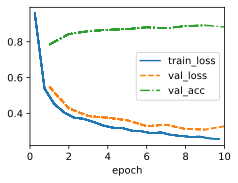

In [3]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)

model = ModernLeNet(lr=0.1)

# Initializes Lazy layers using one real batch
X, y = next(iter(data.get_dataloader(True)))
model.apply_init([X], init_cnn)

trainer.fit(model, data)

In [7]:
model.board.data.keys()

odict_keys(['train_loss', 'val_loss', 'val_acc'])

In [8]:
final_val_acc = model.board.data["val_acc"][-1].y
print("Final validation accuracy:", final_val_acc)

Final validation accuracy: 0.8828125


### Exercise 2

In [15]:
def init_cnn(module):
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        nn.init.xavier_uniform_(module.weight)


class BiggerLeNet(d2l.Classifier):
    def __init__(
        self,
        lr=0.05,
        num_classes=10,
        channels=(32, 64, 128),
        kernel_size=3,
        fc_dims=(256, 128),
        dropout=0.2
    ):
        super().__init__()
        self.save_hyperparameters()

        layers = []

        # Conv block 1
        layers += [
            nn.LazyConv2d(channels[0], kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]

        # Conv block 2
        layers += [
            nn.LazyConv2d(channels[1], kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]

        # Extra conv block
        layers += [
            nn.LazyConv2d(channels[2], kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU()
        ]

        layers += [nn.Flatten()]

        # Fully connected layers
        for dim in fc_dims:
            layers += [
                nn.LazyLinear(dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]

        layers += [nn.LazyLinear(num_classes)]

        self.net = nn.Sequential(*layers)

In [16]:
configs = [
    {
        "name": "small",
        "channels": (16, 32, 64),
        "fc_dims": (128,),
        "lr": 0.05,
        "dropout": 0.1
    },
    {
        "name": "medium",
        "channels": (32, 64, 128),
        "fc_dims": (256, 128),
        "lr": 0.05,
        "dropout": 0.2
    },
    {
        "name": "large",
        "channels": (64, 128, 256),
        "fc_dims": (512, 256),
        "lr": 0.03,
        "dropout": 0.3
    }
]

results = []

for cfg in configs:
    print(f"\nTraining {cfg['name']} model")

    model = BiggerLeNet(
        lr=cfg["lr"],
        channels=cfg["channels"],
        fc_dims=cfg["fc_dims"],
        dropout=cfg["dropout"]
    )

    X, y = next(iter(data.get_dataloader(True)))
    model.apply_init([X], init_cnn)
    
    # Turn off animated plotting so it does not clear your printed output
    model.board.display = False

    trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
    trainer.fit(model, data)

    final_val_acc = model.board.data["val_acc"][-1].y
    
    results.append({
        "name": cfg["name"],
        "val_acc": final_val_acc,
        "lr": cfg["lr"],
        "channels": cfg["channels"],
        "fc_dims": cfg["fc_dims"],
        "dropout": cfg["dropout"]
    })

    print("\nSummary:")
    for r in results:
        print(
            f"{r['name']:>6} | "
            f"val_acc={r['val_acc']:.4f} | "
            f"lr={r['lr']} | "
            f"channels={r['channels']} | "
            f"fc_dims={r['fc_dims']} | "
            f"dropout={r['dropout']}"
        )


Training small model

Summary:
 small | val_acc=0.8983 | lr=0.05 | channels=(16, 32, 64) | fc_dims=(128,) | dropout=0.1

Training medium model

Summary:
 small | val_acc=0.8983 | lr=0.05 | channels=(16, 32, 64) | fc_dims=(128,) | dropout=0.1
medium | val_acc=0.9028 | lr=0.05 | channels=(32, 64, 128) | fc_dims=(256, 128) | dropout=0.2

Training large model

Summary:
 small | val_acc=0.8983 | lr=0.05 | channels=(16, 32, 64) | fc_dims=(128,) | dropout=0.1
medium | val_acc=0.9028 | lr=0.05 | channels=(32, 64, 128) | fc_dims=(256, 128) | dropout=0.2
 large | val_acc=0.8992 | lr=0.03 | channels=(64, 128, 256) | fc_dims=(512, 256) | dropout=0.3


### Exercise 3

In [18]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4
)

Failed to download (trying next):
HTTP Error 404: Not Found



6.0%

100.0%


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

...

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



In [19]:
model = BiggerLeNet(
    lr=0.05,
    channels=(32, 64, 128),
    kernel_size=3,
    fc_dims=(256, 128),
    dropout=0.2
)

X, y = next(iter(data.get_dataloader(True)))
model.apply_init([X], init_cnn)

device = d2l.try_gpu()

model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=model.lr)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 15

In [20]:
for epoch in range(num_epochs):

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        y_hat = model(X)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.shape[0]

        preds = y_hat.argmax(dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.numel()

    train_acc = train_correct / train_total

    # Evaluation
    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            y_hat = model(X)

            preds = y_hat.argmax(dim=1)

            test_correct += (preds == y).sum().item()
            test_total += y.numel()

    test_acc = test_correct / test_total

    print(
        f"Epoch {epoch+1:2d} | "
        f"train_acc={train_acc:.4f} | "
        f"test_acc={test_acc:.4f}"
    )

Epoch  1 | train_acc=0.7980 | test_acc=0.9440
Epoch  2 | train_acc=0.9560 | test_acc=0.9734
Epoch  3 | train_acc=0.9704 | test_acc=0.9785
Epoch  4 | train_acc=0.9769 | test_acc=0.9786
Epoch  5 | train_acc=0.9798 | test_acc=0.9859
Epoch  6 | train_acc=0.9835 | test_acc=0.9889
Epoch  7 | train_acc=0.9855 | test_acc=0.9888
Epoch  8 | train_acc=0.9875 | test_acc=0.9882
Epoch  9 | train_acc=0.9886 | test_acc=0.9896
Epoch 10 | train_acc=0.9890 | test_acc=0.9908
Epoch 11 | train_acc=0.9906 | test_acc=0.9907
Epoch 12 | train_acc=0.9909 | test_acc=0.9905
Epoch 13 | train_acc=0.9919 | test_acc=0.9915
Epoch 14 | train_acc=0.9928 | test_acc=0.9922
Epoch 15 | train_acc=0.9932 | test_acc=0.9916


### Exercise 4

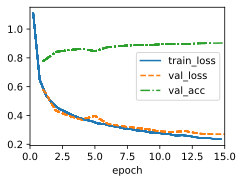

In [21]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from d2l import torch as d2l

data = d2l.FashionMNIST(batch_size=128)

model = BiggerLeNet(
    lr=0.05,
    channels=(32, 64, 128),
    kernel_size=3,
    fc_dims=(256, 128),
    dropout=0.2
)

X, y = next(iter(data.get_dataloader(True)))
model.apply_init([X], init_cnn)

trainer = d2l.Trainer(max_epochs=15, num_gpus=1)
trainer.fit(model, data)



In [22]:
def get_one_example(data, target_label):
    for X, y in data.get_dataloader(False):
        idx = (y == target_label).nonzero(as_tuple=True)[0]  # Get indices where label matches target
        if len(idx) > 0:
            return X[idx[0]:idx[0]+1], y[idx[0]].item()

In [26]:
labels = data.text_labels([
    0,1,2,3,4,5,6,7,8,9
])

print(labels)

['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']


In [27]:
X_pullover, y_pullover = get_one_example(data, 2)
X_coat, y_coat = get_one_example(data, 4)

print(labels[y_pullover])
print(labels[y_coat])

pullover
coat


In [28]:
def get_activations(model, X):
    activations = {}

    X = X.to(next(model.parameters()).device)

    for i, layer in enumerate(model.net):
        X = layer(X)

        if isinstance(layer, nn.Conv2d):    # Only save activations from convolutional layers
            activations[f"conv_{len(activations) + 1}"] = X.detach().cpu()  # Count conv layers to name activations

    return activations

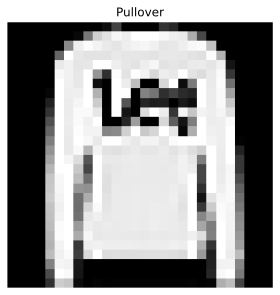

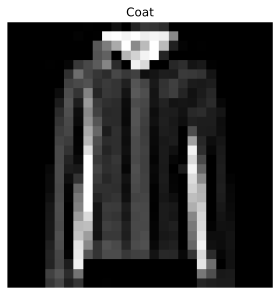

In [29]:
def show_image(X, title):
    plt.imshow(X[0, 0].cpu(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image(X_pullover, "Pullover")
show_image(X_coat, "Coat")

In [35]:
def show_feature_maps(activation, title, max_channels=16):
    activation = activation[0]  # remove batch dimension

    num_channels = min(activation.shape[0], max_channels)

    fig, axes = plt.subplots(1, num_channels, figsize=(1.8 * num_channels, 2))

    if num_channels == 1:
        axes = [axes]

    for i in range(num_channels):
        axes[i].imshow(activation[i], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"ch {i}", fontsize = 10)

    # Add main title
    fig.suptitle(title, fontsize=18, y=1.05)

    # Leave room for suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.show()

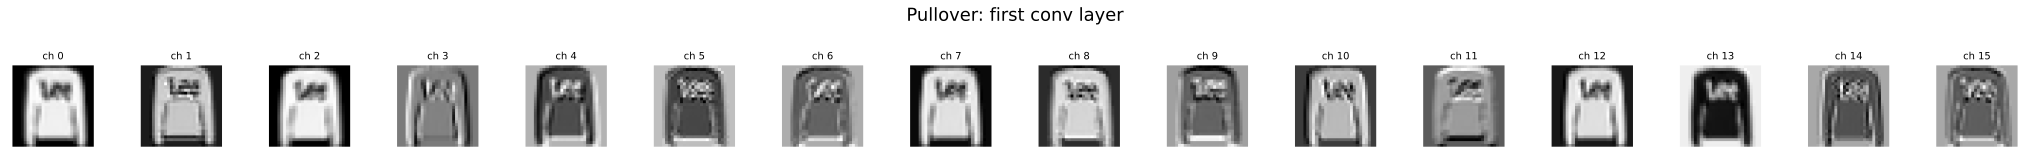

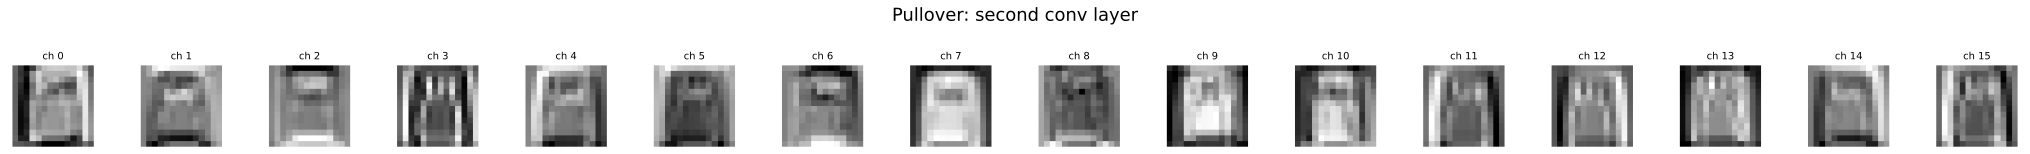

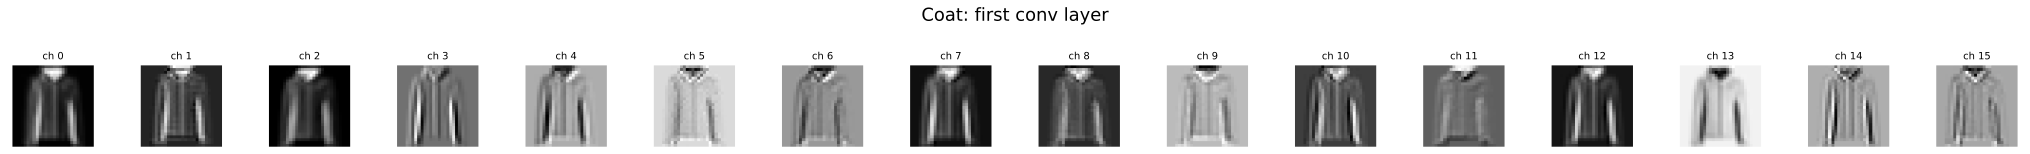

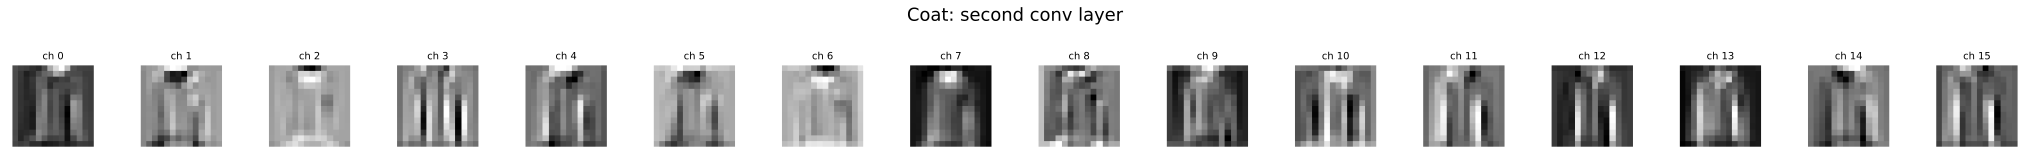

In [36]:
acts_pullover = get_activations(model, X_pullover)
acts_coat = get_activations(model, X_coat)

show_feature_maps(acts_pullover["conv_1"], "Pullover: first conv layer")
show_feature_maps(acts_pullover["conv_2"], "Pullover: second conv layer")

show_feature_maps(acts_coat["conv_1"], "Coat: first conv layer")
show_feature_maps(acts_coat["conv_2"], "Coat: second conv layer")

### Exercise 5

In [37]:
model.eval()

BiggerLeNet(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=6272, out_features=256, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.2, inplace=False)
    (15): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [38]:
X_real, y_real = next(iter(data.get_dataloader(False)))
X_real = X_real[0:1]

In [39]:
X_noise = torch.randn_like(X_real)

In [40]:
X_square = torch.zeros_like(X_real)
X_square[:, :, 8:20, 8:20] = 1.0

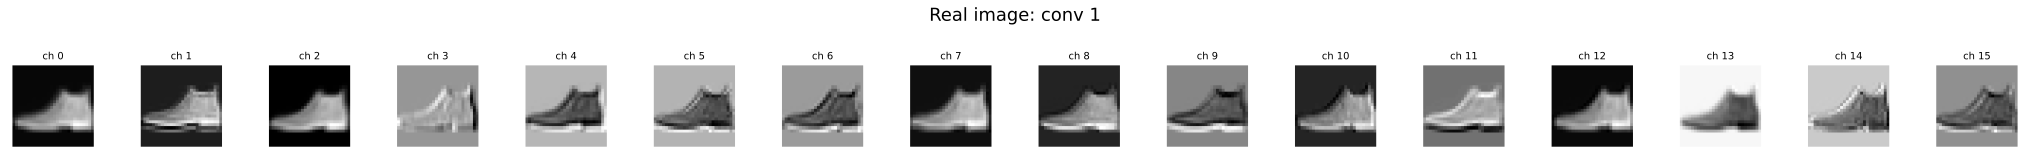

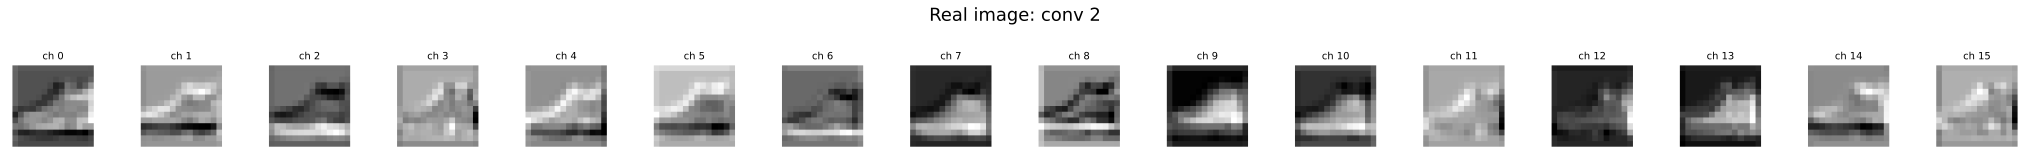

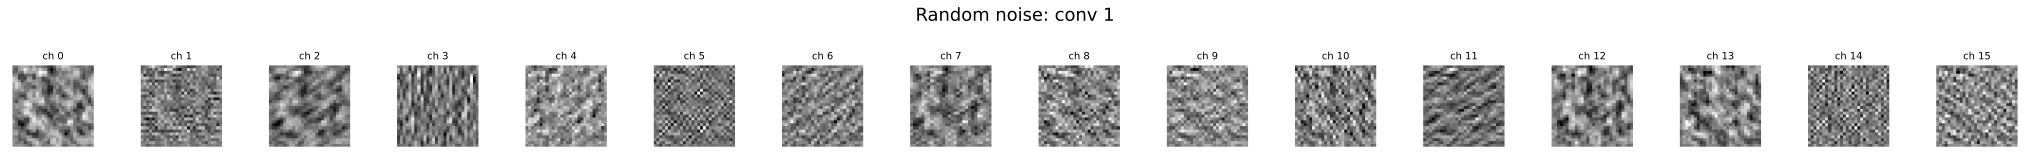

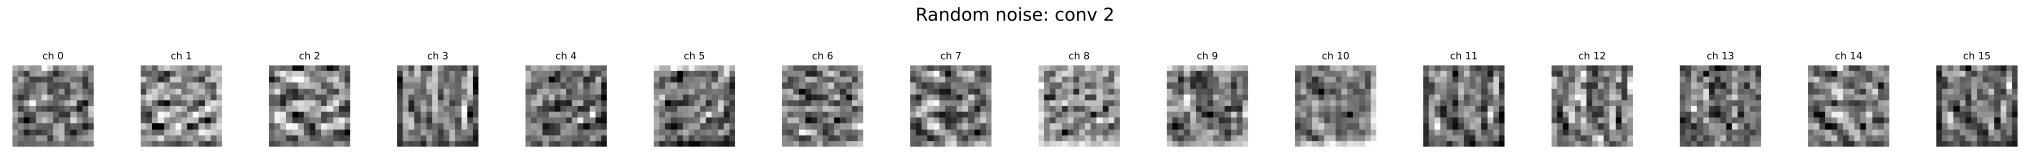

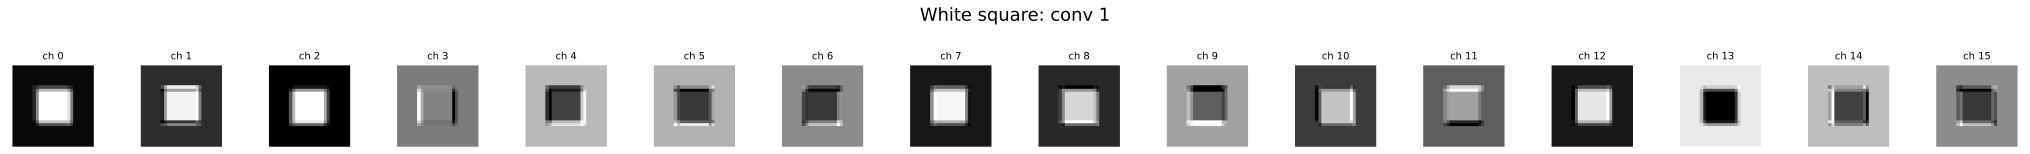

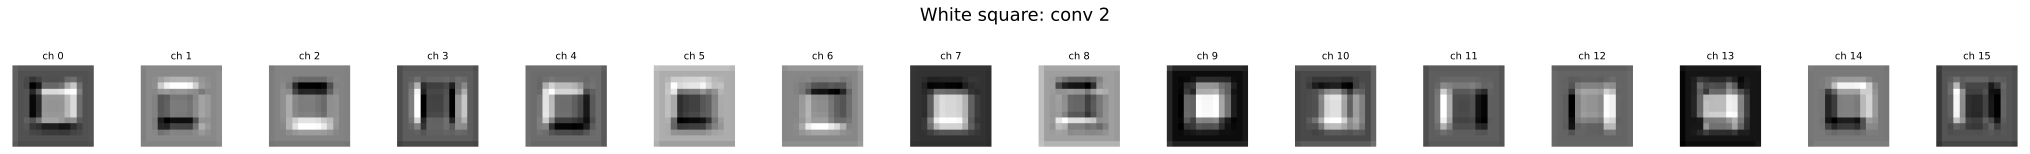

In [41]:
acts_real = get_activations(model, X_real)
acts_noise = get_activations(model, X_noise)
acts_square = get_activations(model, X_square)

show_feature_maps(acts_real["conv_1"], "Real image: conv 1")
show_feature_maps(acts_real["conv_2"], "Real image: conv 2")

show_feature_maps(acts_noise["conv_1"], "Random noise: conv 1")
show_feature_maps(acts_noise["conv_2"], "Random noise: conv 2")

show_feature_maps(acts_square["conv_1"], "White square: conv 1")
show_feature_maps(acts_square["conv_2"], "White square: conv 2")